In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import warnings
import json
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/preprocessed_data.csv', parse_dates=['datetime'])
df = df.sort_values('datetime').reset_index(drop=True)

print(f"Data loaded: {len(df)} rows")
print(f"Columns: {len(df.columns)}")

Data loaded: 44534 rows
Columns: 39


In [2]:
sensor = 'Volume Flow RateRMS'

normal_data = df[df['anomaly'] == 0.0][sensor].values
full_data = df[sensor].values

print(f"Selected sensor: {sensor}")
print(f"Normal data points: {len(normal_data)}")
print(f"Total data points: {len(full_data)}")

print("\nADF Stationarity Test on normal data:")
adf_result = adfuller(normal_data)
print(f"ADF Statistic: {round(adf_result[0], 4)}")
print(f"P-value: {round(adf_result[1], 6)}")
print(f"Critical values:")
for key, value in adf_result[4].items():
    print(f"  {key}: {round(value, 4)}")

if adf_result[1] < 0.05:
    print("\nResult: Series IS stationary (p < 0.05)")
    print("We can fit ARIMA without differencing (d=0)")
else:
    print("\nResult: Series is NOT stationary (p >= 0.05)")
    print("We need differencing (d=1)")

Selected sensor: Volume Flow RateRMS
Normal data points: 32262
Total data points: 44534

ADF Stationarity Test on normal data:
ADF Statistic: -1.6185
P-value: 0.473491
Critical values:
  1%: -3.4306
  5%: -2.8616
  10%: -2.5668

Result: Series is NOT stationary (p >= 0.05)
We need differencing (d=1)


In [3]:
train_size = 2000
train_data = normal_data[:train_size]

print(f"Training ARIMA on {train_size} normal data points...")
print("ARIMA parameters: p=1, d=1, q=1")
print("p=1: uses 1 previous value (autoregression)")
print("d=1: differences once (makes stationary)")
print("q=1: uses 1 previous error (moving average)")

arima_model = ARIMA(train_data, order=(1, 1, 1))
arima_fitted = arima_model.fit()

print("\nARIMA model fitted successfully")
print(f"\nModel summary:")
print(f"AIC score: {round(arima_fitted.aic, 4)}")
print(f"BIC score: {round(arima_fitted.bic, 4)}")
print("\nLower AIC = better model fit")

Training ARIMA on 2000 normal data points...
ARIMA parameters: p=1, d=1, q=1
p=1: uses 1 previous value (autoregression)
d=1: differences once (makes stationary)
q=1: uses 1 previous error (moving average)

ARIMA model fitted successfully

Model summary:
AIC score: -12983.1155
BIC score: -12966.3143

Lower AIC = better model fit


Generating in-sample predictions on training data...
Residual mean: -0.000138
Residual std: 0.009393
Residual min: -0.044836
Residual max: 0.031589


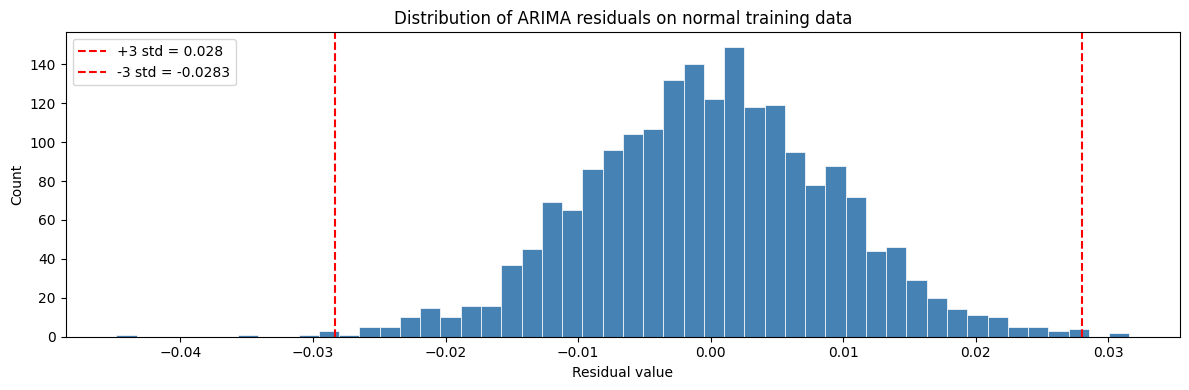

Chart saved to report folder


In [4]:
print("Generating in-sample predictions on training data...")

predictions_train = arima_fitted.fittedvalues

residuals_train = train_data[1:] - predictions_train[1:]

residual_mean = np.mean(residuals_train)
residual_std = np.std(residuals_train)

print(f"Residual mean: {round(residual_mean, 6)}")
print(f"Residual std: {round(residual_std, 6)}")
print(f"Residual min: {round(residuals_train.min(), 6)}")
print(f"Residual max: {round(residuals_train.max(), 6)}")

plt.figure(figsize=(12, 4))
plt.hist(residuals_train, bins=50, color='steelblue', 
         edgecolor='white', linewidth=0.5)
plt.axvline(x=residual_mean + 3*residual_std, 
            color='red', linestyle='--', 
            linewidth=1.5, label=f'+3 std = {round(residual_mean + 3*residual_std, 4)}')
plt.axvline(x=residual_mean - 3*residual_std, 
            color='red', linestyle='--',
            linewidth=1.5, label=f'-3 std = {round(residual_mean - 3*residual_std, 4)}')
plt.title('Distribution of ARIMA residuals on normal training data')
plt.xlabel('Residual value')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('../report/arima_residuals_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to report folder")

## ARIMA residual distribution

Residuals from ARIMA(1,1,1) fitted on normal training data 
follow an approximately normal distribution centered at zero.

This confirms that ARIMA successfully learned the temporal 
pattern of normal Volume Flow RateRMS behavior.

Anomaly threshold set at mean ± 3 standard deviations:
- Upper threshold: +0.028
- Lower threshold: -0.028

Any future reading producing a residual outside this range 
is flagged as anomalous — statistically unlikely under 
normal operating conditions.